# TensorFlow

TensorFlow CNN tutorial on the MNIST dataset.

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

In [2]:
LEARNING_RATE = 0.001
NUM_EPOCHS = 25
BATCH_SIZE = 128

In [3]:
# load the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [4]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

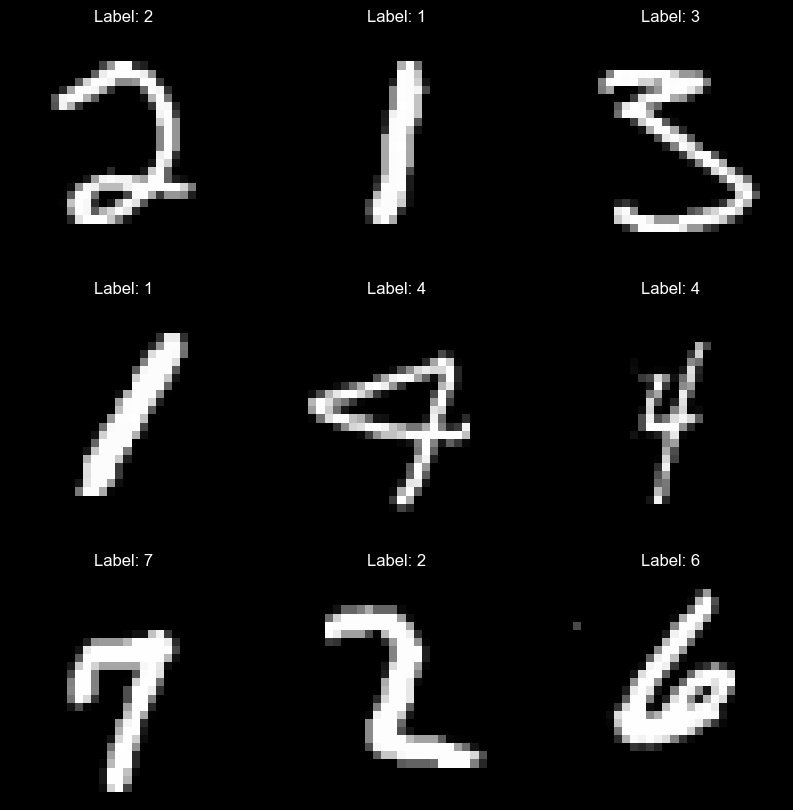

In [6]:
# display examples from the training set 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i in range(3):
    for j in range(3):
        random_idx = np.random.randint(x_train.shape[0])
        axes[i, j].imshow(x_train[random_idx], cmap='gray')
        axes[i, j].set_title(f'Label: {y_train[random_idx]}')
        axes[i, j].axis('off')
plt.show()

In [7]:
# normalize the pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [8]:
# reshape the data to add a channel dimension
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]


In [9]:
# create a simple CNN model based on the ResNet architecture
model = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1), name="input"),
    keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu', name="conv1"),
    keras.layers.MaxPooling2D(pool_size=(2, 2), name="pool1"),
    keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu', name="conv2"),
    keras.layers.MaxPooling2D(pool_size=(2, 2), name="pool2"),
    keras.layers.Flatten(name="flatten"),
    keras.layers.Dense(128, activation='relu', name="hidden-1"),
    keras.layers.Dense(10, activation='softmax', name="output")
])

2026-03-16 10:35:55.477629: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-03-16 10:35:55.477684: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-16 10:35:55.477693: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-16 10:35:55.477720: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-16 10:35:55.477736: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [10]:
# compile the model
model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden-1 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# early stopping callback
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [13]:
# train the model
history = model.fit(x_train, y_train,
                    epochs=NUM_EPOCHS,
                    batch_size=BATCH_SIZE,
                    verbose=1,
                    callbacks=[early_stopping],
                    validation_data=(x_test, y_test),
                    shuffle=True
)

Epoch 1/25


2026-03-16 10:36:42.911207: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9331 - loss: 0.2174 - val_accuracy: 0.9763 - val_loss: 0.0693
Epoch 2/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9793 - loss: 0.0669 - val_accuracy: 0.9834 - val_loss: 0.0491
Epoch 3/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9834 - loss: 0.0541 - val_accuracy: 0.9849 - val_loss: 0.0441
Epoch 4/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9847 - loss: 0.0502 - val_accuracy: 0.9858 - val_loss: 0.0561
Epoch 5/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9853 - loss: 0.0501 - val_accuracy: 0.9800 - val_loss: 0.0723
Epoch 6/25
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9868 - loss: 0.0526 - val_accuracy: 0.9872 - val_loss: 0.0602


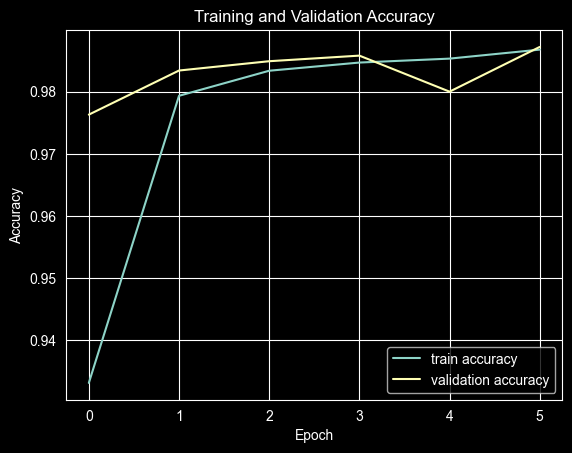

In [14]:
# plot training and validation accuracy
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

In [15]:
# test the model
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Test accuracy: {test_acc:.4f}')

313/313 - 1s - 3ms/step - accuracy: 0.9849 - loss: 0.0441
Test accuracy: 0.9849


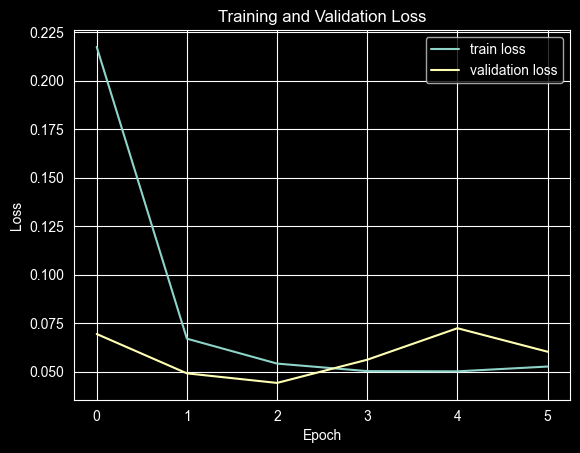

In [16]:
# plot the train and validation loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


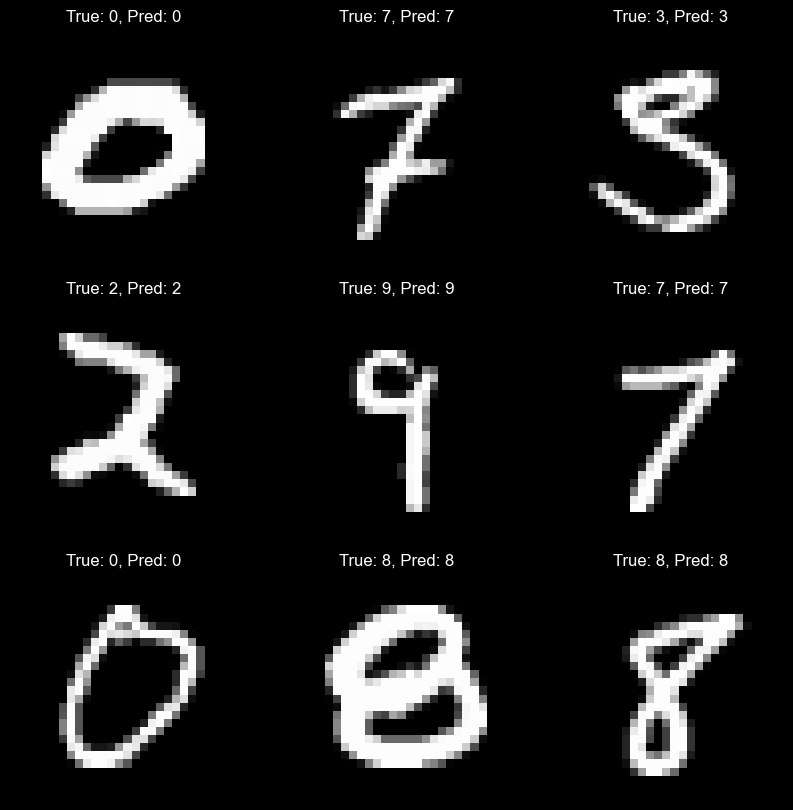

In [17]:
# plot the number + label + prediction for 9 random test samples
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i in range(3):
    for j in range(3):
        random_idx = np.random.randint(x_test.shape[0])
        axes[i, j].imshow(x_test[random_idx].squeeze(), cmap='gray')
        true_label = y_test[random_idx]
        pred_label = np.argmax(model.predict(x_test[random_idx][tf.newaxis, ...]))
        axes[i, j].set_title(f'True: {true_label}, Pred: {pred_label}')
        axes[i, j].axis('off')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


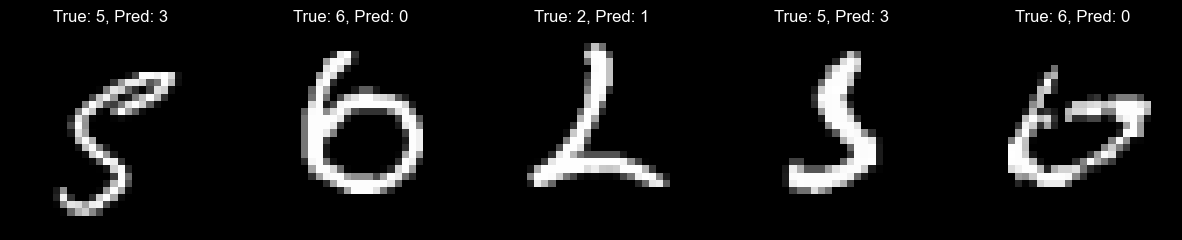

In [18]:
# in the test set find the first 5 misclassified samples and plot them with their true and predicted labels
misclassified_indices = np.where(np.argmax(model.predict(x_test), axis=1) != y_test)[0]
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    idx = misclassified_indices[i]
    axes[i].imshow(x_test[idx].squeeze(), cmap='gray')
    true_label = y_test[idx]
    pred_label = np.argmax(model.predict(x_test[idx][tf.newaxis, ...]))
    axes[i].set_title(f'True: {true_label}, Pred: {pred_label}')
    axes[i].axis('off')
plt.show()

In [20]:
# save the whole model
model.save('mnist_cnn_model.keras')

In [21]:
# load the model into model2
model2 = keras.models.load_model('mnist_cnn_model.keras')

In [22]:
# evaluate the loaded model
test_loss, test_acc = model2.evaluate(x_test, y_test, verbose=2)
print(f'Test accuracy of loaded model: {test_acc:.4f}')

313/313 - 1s - 3ms/step - accuracy: 0.9849 - loss: 0.0441
Test accuracy of loaded model: 0.9849
